## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [ ]:
X_train = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Data\processed_data\train\X_train.csv")

X_test = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Data\processed_data\test\X_test.csv")

y_train = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Data\processed_data\train\y_train.csv").squeeze()

y_test = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Data\processed_data\test\y_test.csv").squeeze()

In [3]:
model = joblib.load(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\models\best_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


## Initializing SHAP Explainer

In [4]:
explainer = shap.TreeExplainer(model)

## Generating SHAP Values

In [5]:
shap_values = explainer.shap_values(X_test)

print(type(shap_values))

<class 'numpy.ndarray'>


## SHAP Summary Plot

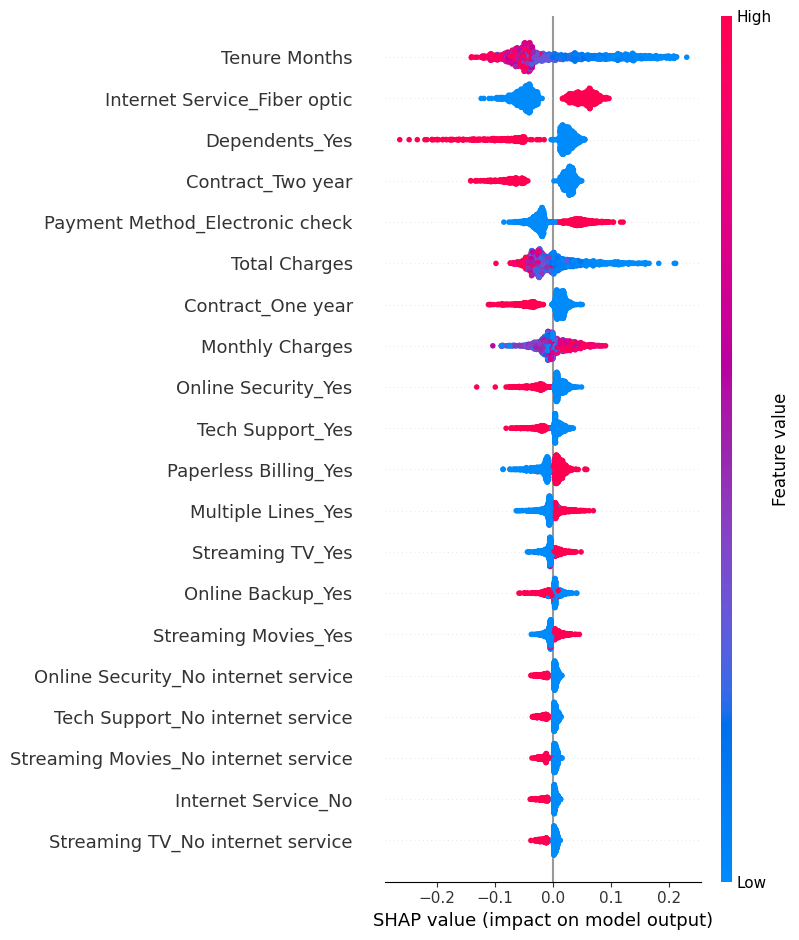

In [6]:
shap.summary_plot(shap_values[:, :, 1],X_test)

## Bar Plot

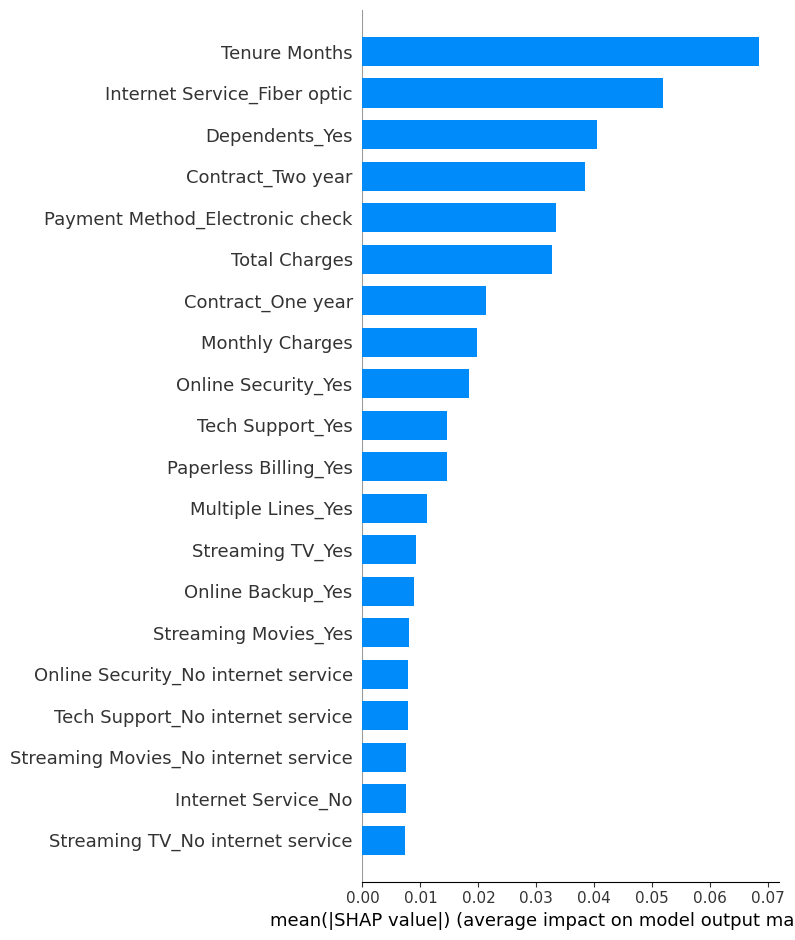

In [7]:
shap.summary_plot(shap_values[:, :, 1],X_test,plot_type="bar")

## Feature Importance Table

In [8]:
importance = pd.DataFrame({
                            "Feature": X_test.columns,
                            "Importance": np.abs(shap_values[:, :, 1]).mean(axis=0)})

importance = importance.sort_values(by="Importance",ascending=False)

importance.head(10)

,Feature,Importance
0,Tenure Months,0.068370
10,Internet Service_Fiber optic,0.051864
6,Dependents_Yes,0.040431
25,Contract_Two year,0.038355
28,Payment Method_Electronic check,0.033392
2,Total Charges,0.032733
24,Contract_One year,0.021228
1,Monthly Charges,0.019835
13,Online Security_Yes,0.018343
19,Tech Support_Yes,0.014602


## Saving Feature Importance

In [9]:
importance.to_csv("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\reports\\shap_feature_importance.csv", index=False)

## Dependence Plot

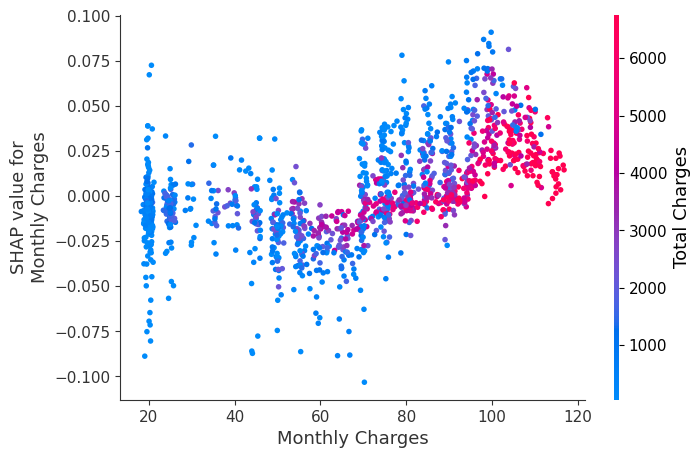

In [10]:
shap.dependence_plot("Monthly Charges",shap_values[:, :, 1],X_test)

In [14]:
print(type(shap_values))

print(shap_values.shape)

print(type(explainer))

<class 'numpy.ndarray'>
(1409, 30, 2)
<class 'shap.explainers._tree.TreeExplainer'>


## Waterfall Plot

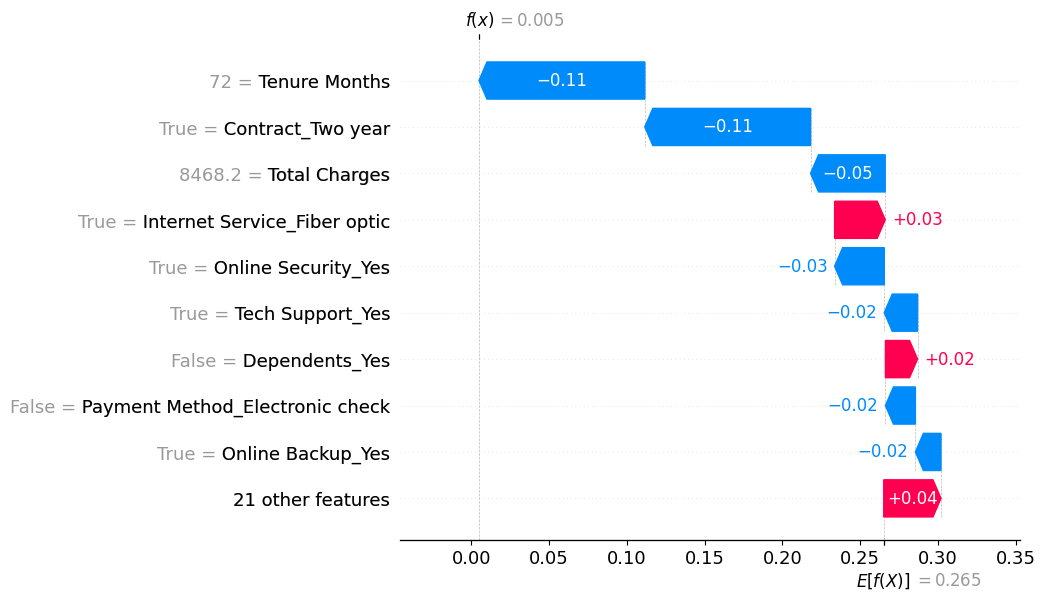

In [ ]:
customer = 0

explanation = shap.Explanation(
    values=shap_values[customer, :, 1],      # SHAP values for Churn class
    base_values=explainer.expected_value[1],
    data=X_test.iloc[customer],
    feature_names=X_test.columns)

shap.plots.waterfall(explanation)

In [ ]:
print(explainer.expected_value)

[0.73492013 0.26507987]
